## Titanic Dataset - Data Cleaning & Exploratory Data Analysis (EDA)


In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [84]:
train = pd.read_csv('titanic_train.csv')
test = pd.read_csv('titanic_test.csv')

print('Train shape:', train.shape)
print('Test shape :', test.shape)
train.head()

Train shape: (891, 12)
Test shape : (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [85]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [86]:
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [87]:
train.describe(include='object')

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,G6,S
freq,1,577,7,4,644


In [88]:
# Finding the missing values before cleaning
missing = train.isnull().sum()
miss = (missing / len(train) *100).round(2)

pd.DataFrame({'count': missing, 'missing(%)': miss}).query('count > 0')

,count,missing(%)
Age,177,19.87
Cabin,687,77.10
Embarked,2,0.22


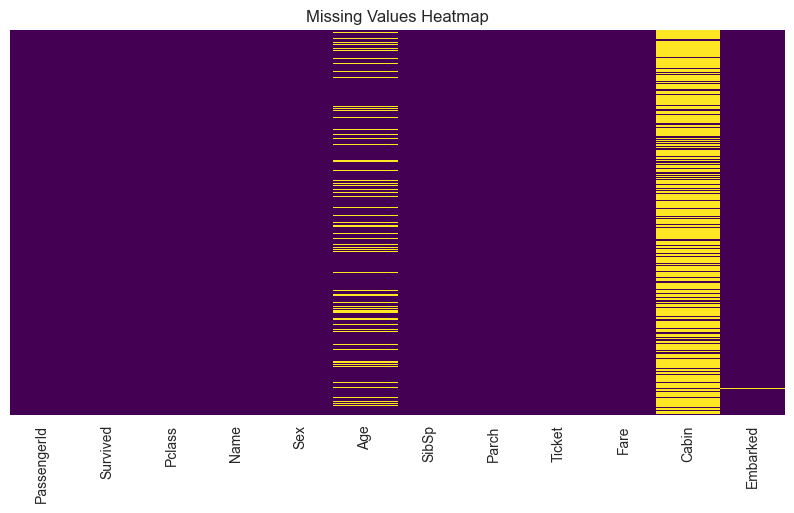

In [89]:
sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

plt.figure(figsize=(10, 5))
sns.heatmap(train.isnull(), yticklabels=False, cbar=False, cmap='viridis')

plt.title('Missing Values Heatmap')
plt.show()

**From the above heatmap, we can see that:**
- `Age` is missing for 177 passengers (20%)
- `Cabin` is missing for 687 passengers (77%)
- `Embarked` is missing for only 2 passengers

### Data Cleaning

In [90]:
age_med = train.groupby(['Sex', 'Pclass'])['Age'].median()
age_med

Sex     Pclass
female  1         35.0
        2         28.0
        3         21.5
male    1         40.0
        2         30.0
        3         25.0
Name: Age, dtype: float64

In [91]:
train['Age'] = train.groupby(['Sex', 'Pclass'])['Age'].transform(lambda x: x.fillna(x.median()))
test['Age'] = test.groupby(['Sex', 'Pclass'])['Age'].transform(lambda x: x.fillna(x.median()))

print('Missing \'age\' values remaining:', train['Age'].isnull().sum())

Missing 'age' values remaining: 0


In [92]:
mode_embarked = train['Embarked'].mode()[0]
train['Embarked'] = train['Embarked'].fillna(mode_embarked)

print('Most common port:', mode_embarked)
print('Missing \'embarked\' values remaining:', train['Embarked'].isnull().sum())

Most common port: S
Missing 'embarked' values remaining: 0


In [93]:
train['Has_Cabin'] = train['Cabin'].notnull().astype(int)
train.drop(columns=['Cabin'], inplace=True)

train.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
Has_Cabin      0
dtype: int64

### Feature Engineering

In [94]:
train['Title'] = train['Name'].str.extract(r',\s*([^\.]*)\.')
train['Title'].value_counts()

Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Col               2
Mlle              2
Major             2
Ms                1
Mme               1
Don               1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64

In [95]:
# Grouping rare titles into broader categories
title_map = {
    'Mr': 'Mr', 'Miss': 'Miss', 'Mrs': 'Mrs', 'Master': 'Master', 'Mlle': 'Miss',
    'Ms': 'Miss', 'Mme': 'Mrs',
    'Dr': 'Officer/Royalty', 'Rev': 'Officer/Royalty', 'Col': 'Officer/Royalty',
    'Major': 'Officer/Royalty', 'Capt': 'Officer/Royalty', 'Sir': 'Officer/Royalty',
    'Lady': 'Officer/Royalty', 'Don': 'Officer/Royalty', 'Jonkheer': 'Officer/Royalty',
    'the Countess': 'Officer/Royalty'
}

train['Title'] = train['Title'].map(title_map)
train['Title'].value_counts()

Title
Mr                 517
Miss               185
Mrs                126
Master              40
Officer/Royalty     23
Name: count, dtype: int64

In [96]:
train['FamilySize'] = train['SibSp'] + train['Parch'] + 1
train['IsAlone'] = (train['FamilySize'] == 1).astype(int)

train[['Name', 'Title', 'SibSp', 'Parch', 'FamilySize', 'IsAlone']].head()

,Name,Title,SibSp,Parch,FamilySize,IsAlone
0,"Braund, Mr. Owen Harris",Mr,1,0,2,0
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Mrs,1,0,2,0
2,"Heikkinen, Miss. Laina",Miss,0,0,1,1
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Mrs,1,0,2,0
4,"Allen, Mr. William Henry",Mr,0,0,1,1


C:\Users\kcdar\AppData\Local\Temp\ipykernel_23280\1776979120.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived', data=train, ax=axes[0], palette=['#DE1A24', '#3F8F29'])
C:\Users\kcdar\AppData\Local\Temp\ipykernel_23280\1776979120.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Pclass', data=train, ax=axes[1], palette=['#A9CCE3', '#5499C7', '#2471A3'])


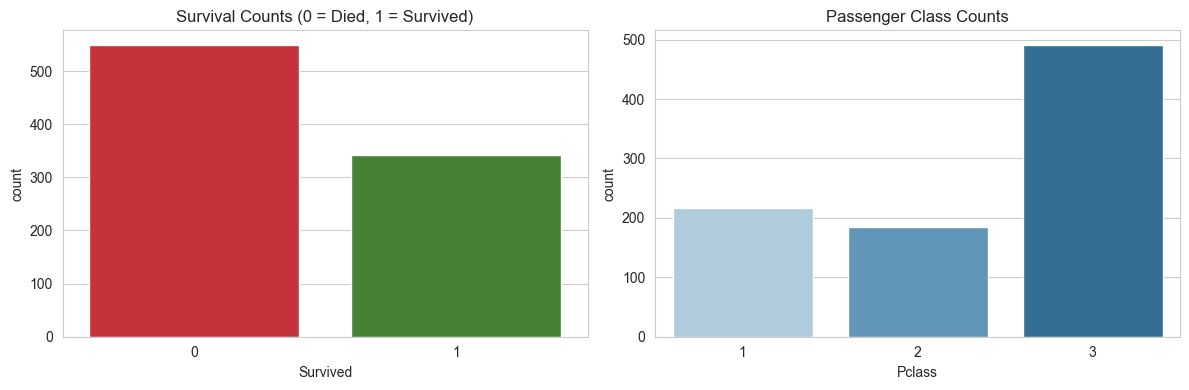

Overall survival rate: 38.4%


In [97]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(x='Survived', data=train, ax=axes[0], palette=['#DE1A24', '#3F8F29'])
axes[0].set_title('Survival Counts (0 = Died, 1 = Survived)')

sns.countplot(x='Pclass', data=train, ax=axes[1], palette=['#A9CCE3', '#5499C7', '#2471A3'])
axes[1].set_title('Passenger Class Counts')

plt.tight_layout()
plt.show()

print('Overall survival rate: {:.1%}'.format(train['Survived'].mean()))

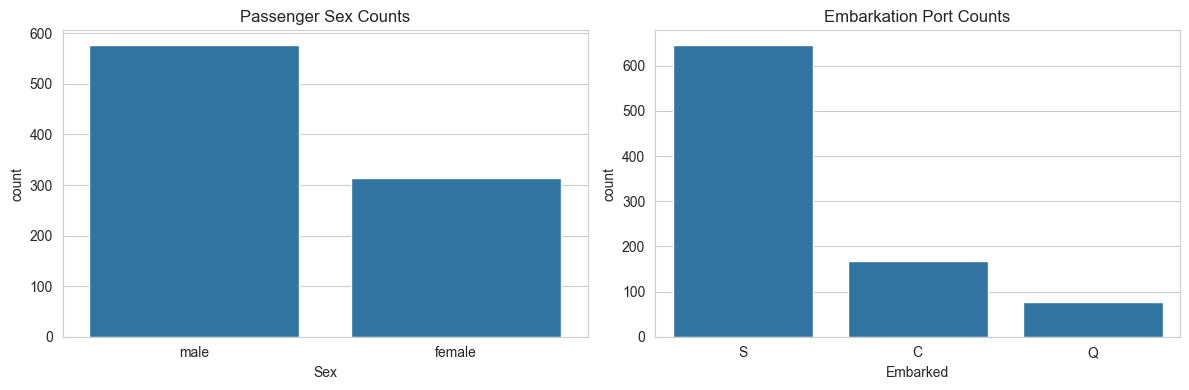

In [98]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x='Sex', data=train, ax=axes[0])
axes[0].set_title('Passenger Sex Counts')

sns.countplot(x='Embarked', data=train, ax=axes[1])
axes[1].set_title('Embarkation Port Counts')
plt.tight_layout()
plt.show()

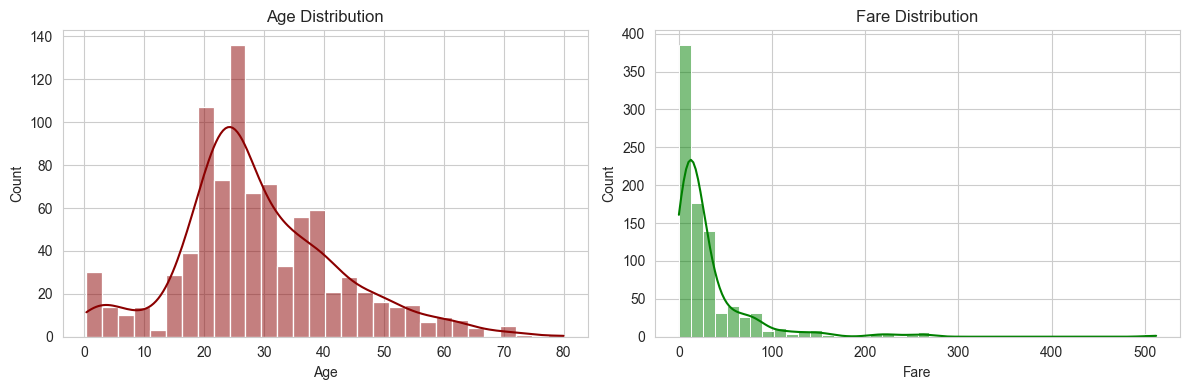

In [99]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(train['Age'], bins=30, kde=True, color='darkred', ax=axes[0])
axes[0].set_title('Age Distribution')

sns.histplot(train['Fare'], bins=40, kde=True, color='green', ax=axes[1])
axes[1].set_title('Fare Distribution')
plt.tight_layout()
plt.show()

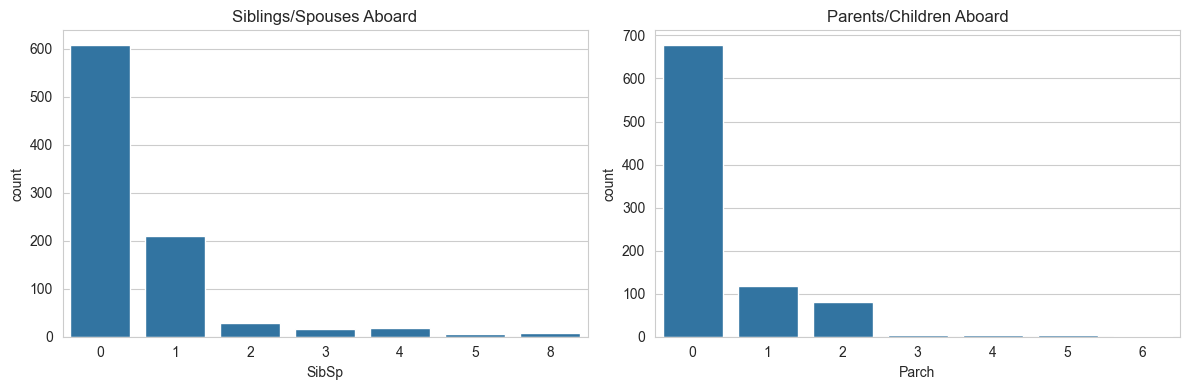

In [100]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x='SibSp', data=train, ax=axes[0])
axes[0].set_title('Siblings/Spouses Aboard')

sns.countplot(x='Parch', data=train, ax=axes[1])
axes[1].set_title('Parents/Children Aboard')
plt.tight_layout()
plt.show()

**Observations:**
- More passengers died than survived overall (~62% died, ~38% survived).
- Most passengers traveled in 3rd class, and most embarked from Southampton (S).
- Age is roughly bell-shaped, concentrated between 20–40, with a small bump of infants/children.
- Fare is heavily right-skewed — most tickets were cheap, with a small number of very expensive ones.
- Most passengers traveled alone or with just one family member.

### Relationships With Survival

#### Survival by Sex

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


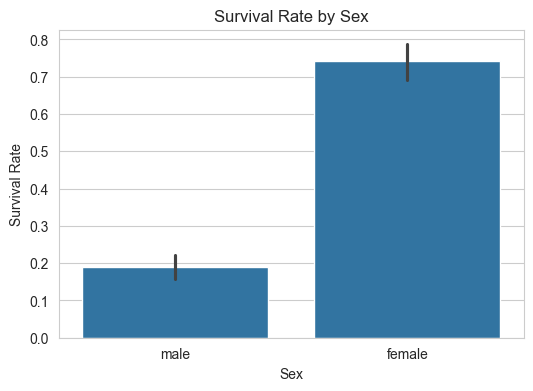

In [101]:
print(train.groupby('Sex')['Survived'].mean())

plt.figure(figsize=(6, 4))
sns.barplot(x='Sex', y='Survived', data=train)
plt.title('Survival Rate by Sex')
plt.ylabel('Survival Rate')
plt.show()

#### Survival by Passenger Class

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


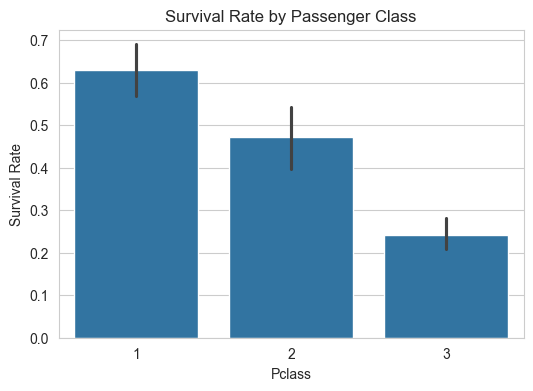

In [102]:
print(train.groupby('Pclass')['Survived'].mean())

plt.figure(figsize=(6, 4))
sns.barplot(x='Pclass', y='Survived', data=train)
plt.title('Survival Rate by Passenger Class')
plt.ylabel('Survival Rate')
plt.show()

In [103]:
pd.crosstab([train.Sex, train.Pclass], train.Survived, margins=True)

Survived         0    1  All
Sex    Pclass               
female 1         3   91   94
       2         6   70   76
       3        72   72  144
male   1        77   45  122
       2        91   17  108
       3       300   47  347
All            549  342  891

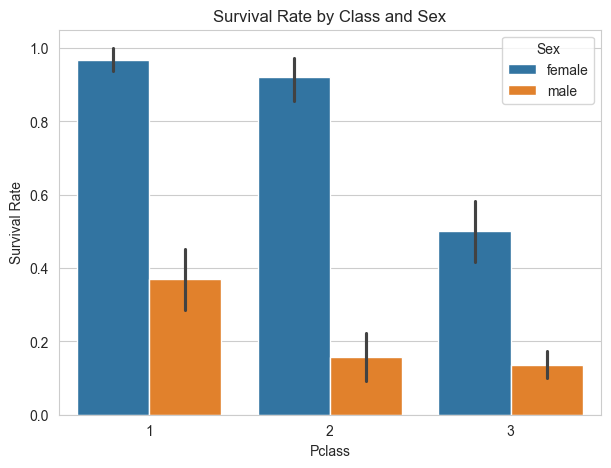

In [104]:
plt.figure(figsize=(7, 5))
sns.barplot(x='Pclass', y='Survived', hue='Sex', data=train)
plt.title('Survival Rate by Class and Sex')
plt.ylabel('Survival Rate')
plt.show()

#### Age and Survival

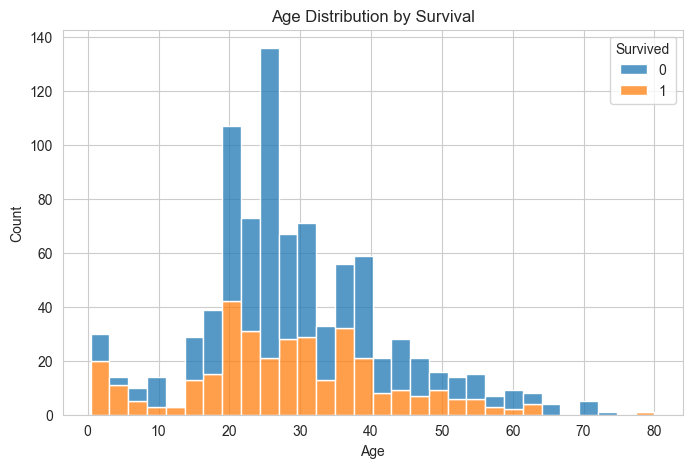

In [105]:
plt.figure(figsize=(8, 5))
sns.histplot(data=train, x='Age', hue='Survived', multiple='stack', bins=30)
plt.title('Age Distribution by Survival')
plt.show()

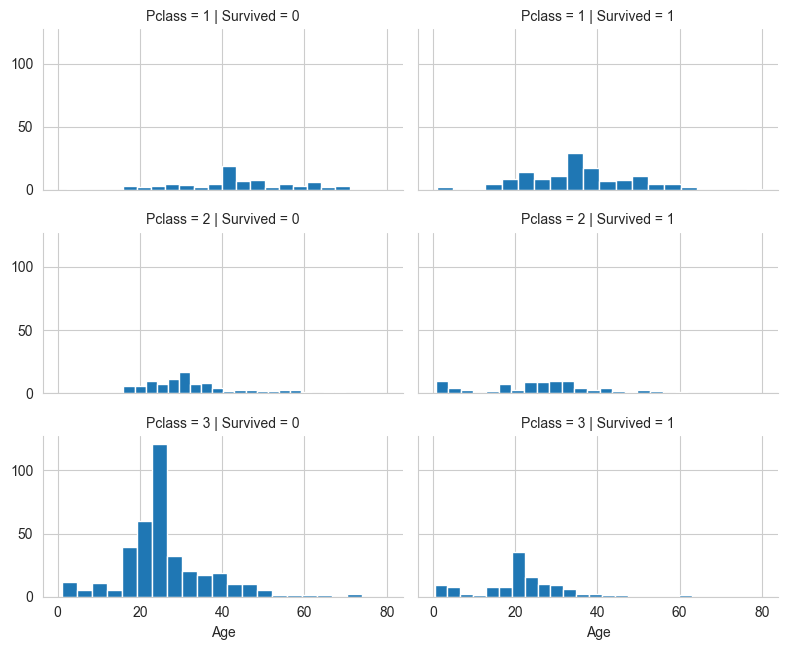

In [106]:
g = sns.FacetGrid(train, col='Survived', row='Pclass', height=2.2, aspect=1.8)
g.map(plt.hist, 'Age', bins=20)
g.add_legend()
plt.show()

#### Fare and Survival

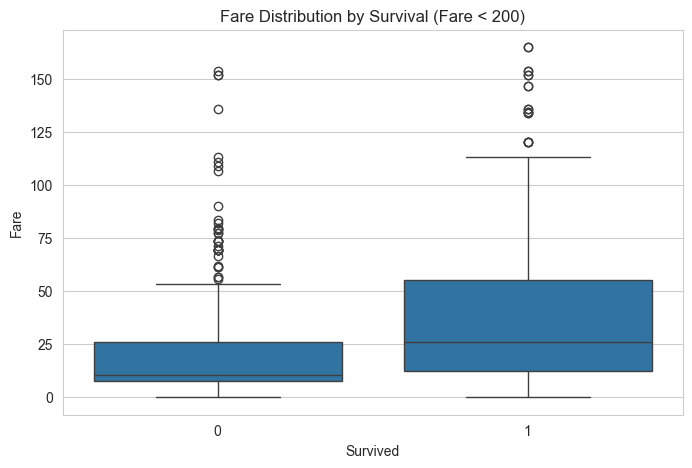

In [107]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Survived', y='Fare', data=train[train['Fare'] < 200])
plt.title('Fare Distribution by Survival (Fare < 200)')
plt.show()

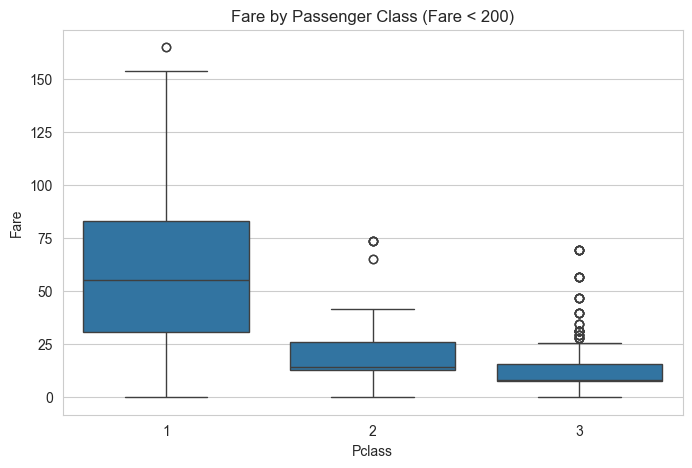

In [108]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Pclass', y='Fare', data=train[train['Fare'] < 200])
plt.title('Fare by Passenger Class (Fare < 200)')
plt.show()

#### Embarkation Port and Survival

Embarked
C    0.553571
Q    0.389610
S    0.339009
Name: Survived, dtype: float64


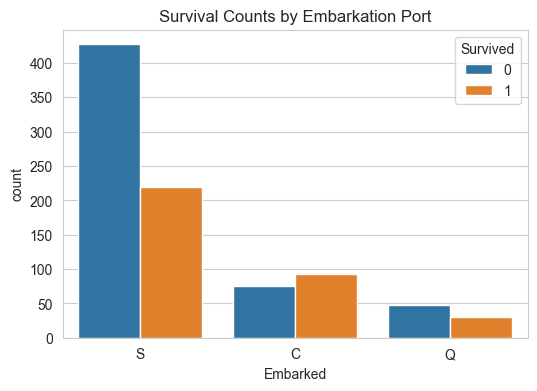

In [109]:
print(train.groupby('Embarked')['Survived'].mean())

plt.figure(figsize=(6, 4))
sns.countplot(x='Embarked', hue='Survived', data=train)
plt.title('Survival Counts by Embarkation Port')
plt.show()

#### Family Size and Survival

FamilySize
1     0.303538
2     0.552795
3     0.578431
4     0.724138
5     0.200000
6     0.136364
7     0.333333
8     0.000000
11    0.000000
Name: Survived, dtype: float64


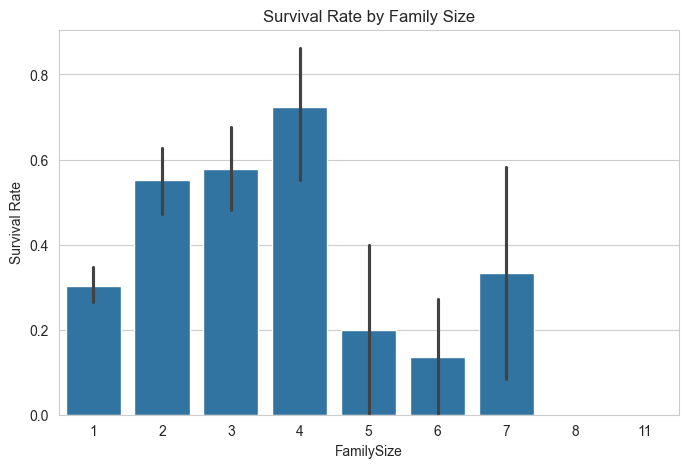

In [110]:
print(train.groupby('FamilySize')['Survived'].mean())

plt.figure(figsize=(8, 5))
sns.barplot(x='FamilySize', y='Survived', data=train)
plt.title('Survival Rate by Family Size')
plt.ylabel('Survival Rate')
plt.show()

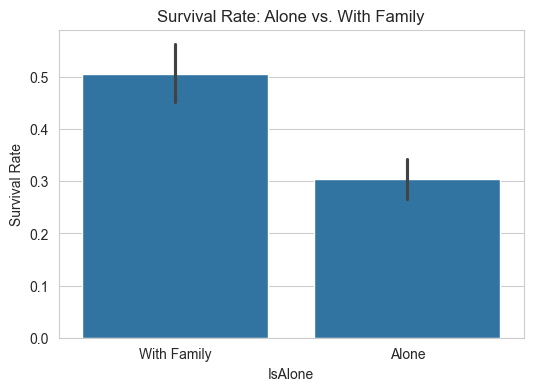

In [111]:
plt.figure(figsize=(6, 4))
sns.barplot(x='IsAlone', y='Survived', data=train)
plt.xticks([0, 1], ['With Family', 'Alone'])
plt.title('Survival Rate: Alone vs. With Family')
plt.ylabel('Survival Rate')
plt.show()

#### Title and Survival

Title
Mrs                0.793651
Miss               0.702703
Master             0.575000
Officer/Royalty    0.347826
Mr                 0.156673
Name: Survived, dtype: float64


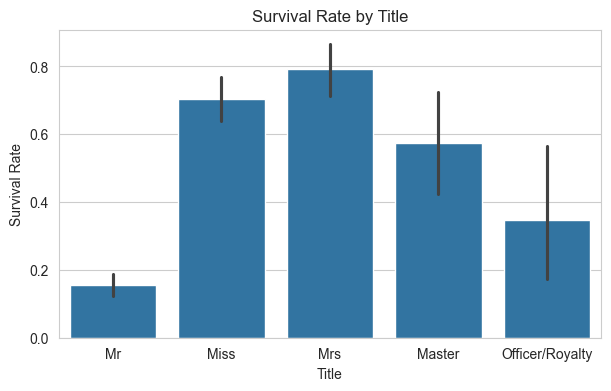

In [112]:
print(train.groupby('Title')['Survived'].mean().sort_values(ascending=False))

plt.figure(figsize=(7, 4))
sns.barplot(x='Title', y='Survived', data=train, order=train['Title'].value_counts().index)
plt.title('Survival Rate by Title')
plt.ylabel('Survival Rate')
plt.show()

#### Cabin Recorded and Survival

Has_Cabin
0    0.299854
1    0.666667
Name: Survived, dtype: float64


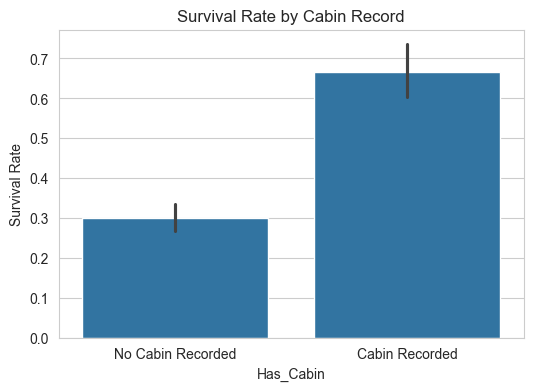

In [113]:
print(train.groupby('Has_Cabin')['Survived'].mean())

plt.figure(figsize=(6, 4))
sns.barplot(x='Has_Cabin', y='Survived', data=train)
plt.xticks([0, 1], ['No Cabin Recorded', 'Cabin Recorded'])
plt.title('Survival Rate by Cabin Record')
plt.ylabel('Survival Rate')
plt.show()

### Correlation Analysis


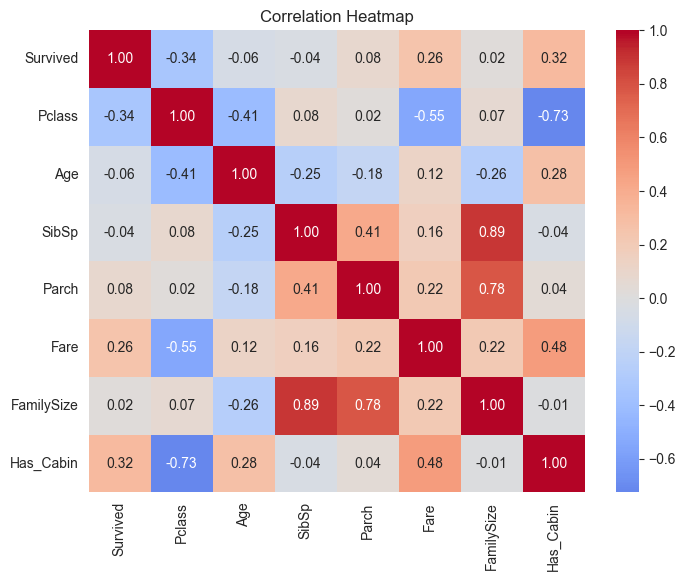

In [114]:
numeric_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'Has_Cabin']
corr = train[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

In [115]:
corr['Survived'].sort_values(ascending=False)

Survived      1.000000
Has_Cabin     0.316912
Fare          0.257307
Parch         0.081629
FamilySize    0.016639
SibSp        -0.035322
Age          -0.059579
Pclass       -0.338481
Name: Survived, dtype: float64

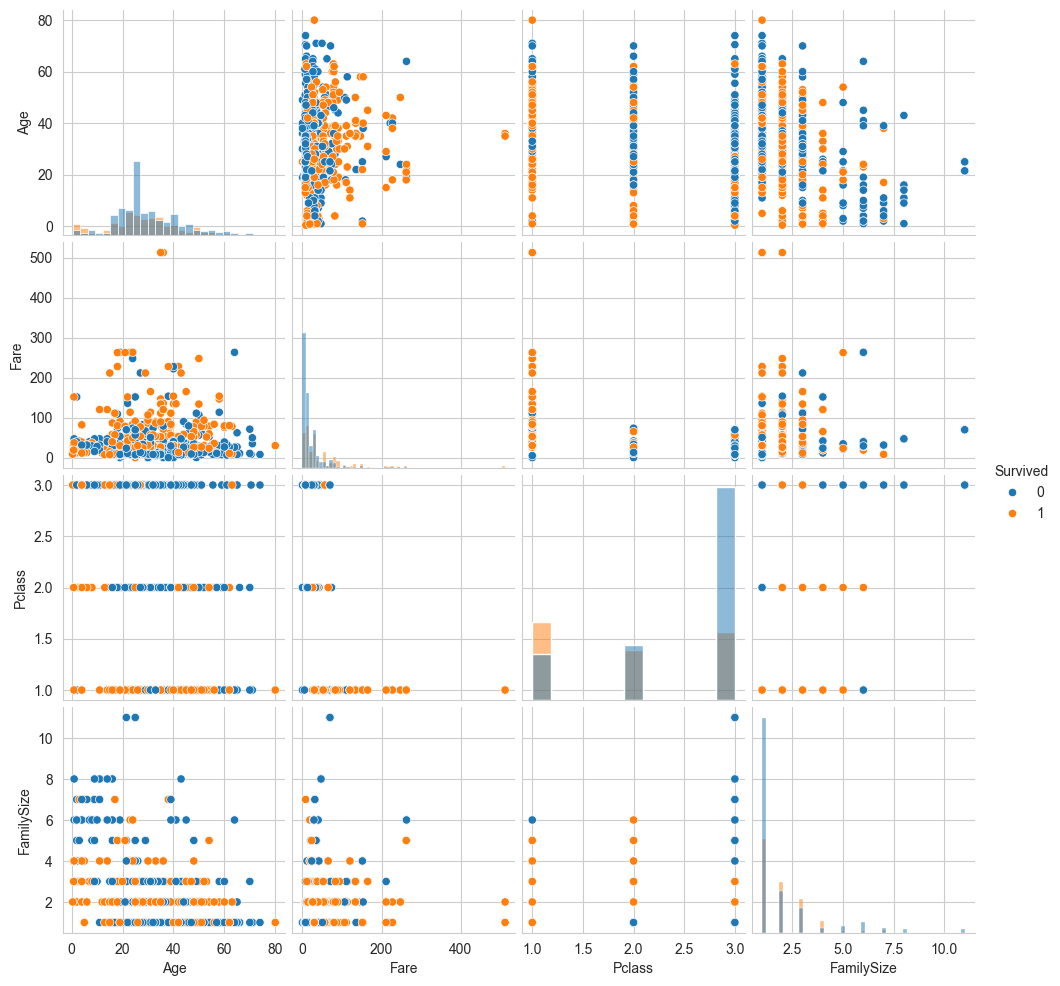

In [116]:
sns.pairplot(train[['Survived', 'Age', 'Fare', 'Pclass', 'FamilySize']].dropna(), hue='Survived', diag_kind='hist')
plt.show()

#

#

#

#

#

#

#

#

#

## 10. Key Insights

- **Sex was the single strongest factor**: women survived at roughly 74%, vs. about 19% for men.
- **Passenger class mattered a lot**: 1st class passengers survived at ~63%, vs. ~47% for 2nd class and ~24% for 3rd class — wealthier passengers had better access to lifeboats.
- **Class and sex compound**: 1st class women had the highest survival rate of any group; 3rd class men had the lowest.
- **Age played a secondary role**: young children had noticeably higher survival rates than adult men, consistent with a "women and children first" pattern, but age alone is a weaker predictor than sex or class.
- **Fare correlates with class and survival**: passengers who paid higher fares (mostly 1st class) survived at higher rates; `Fare` and `Pclass` are negatively correlated as expected.
- **Family size shows a mild non-monotonic pattern**: passengers traveling completely alone or in very large families (5+) had lower survival rates than those in small families (2–4), who may have helped each other while not being held up by large groups.
- **Title (a proxy for age/sex/status) cleanly separates groups**: "Mrs" and "Miss" have high survival, "Mr" has the lowest, "Master" (young boys) sits in between.
- **Cabin / Embarked are weaker, secondary signals**: having a recorded cabin correlates with being in a higher class (and therefore higher survival), and Cherbourg embarkers had a somewhat higher survival rate, likely reflecting the higher proportion of 1st class passengers boarding there.

Overall, **sex and passenger class are the dominant drivers of survival**, with age, fare, family size and title adding secondary, partly overlapping signal.